# Plotting the Cell Voltage Curve Against OCV (Graphite)

../MSU_HPCC/Graphite-half-cell-13727369.SLURMout
Points found: 60
   XfrC_avg     VCell    Cp_min    Cp_max
0  0.030000  0.368600  0.030000  0.030002
1  0.047061  0.208625  0.031250  0.052850
2  0.066153  0.199626  0.037855  0.092416
3  0.085202  0.183229  0.042375  0.117757
4  0.104181  0.158232  0.047553  0.137770


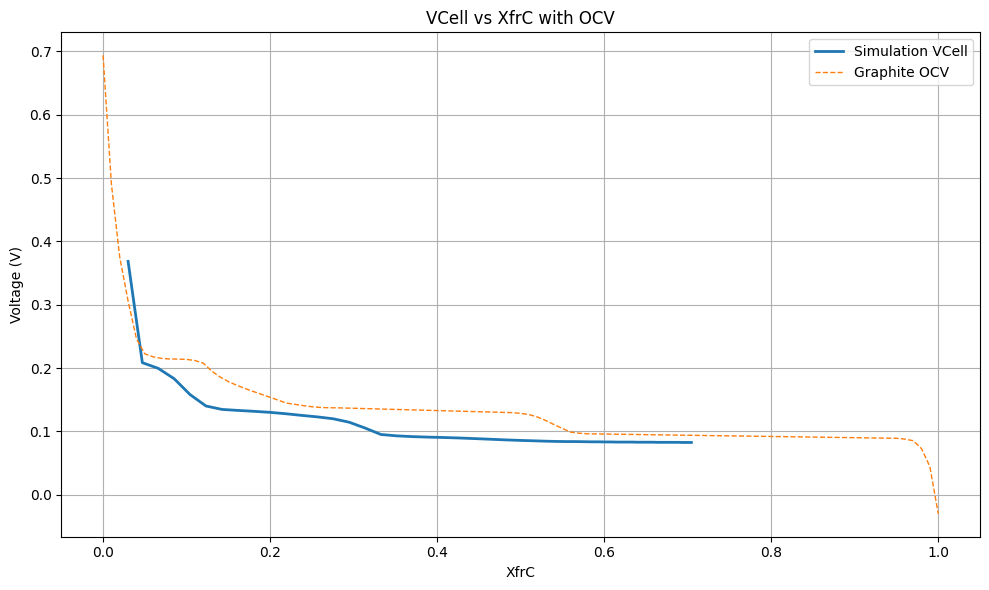

In [61]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/Graphite-half-cell-13727369.SLURMout"
)


# ============================================================
# STEP 2: LOAD Graphite OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

# ============================================================
# STEP 3: INTERPOLATE OCV AT SIMULATION XfrC VALUES
# ============================================================

df1["ocv"] = np.interp(df1["XfrC_avg"], ticks, ocv)

# ============================================================
# STEP 4: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation VCell"
)

# OCV curve
plt.plot(
    ticks,
    ocv,
    '--',
    linewidth=1,
    label="Graphite OCV"
)

plt.xlabel("XfrC")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrC with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# Plotting the Cell Voltage Curve Against OCV (NMC)

../MSU_HPCC/NMC-half-cell-13724576.SLURMout
Points found: 33
   XfrC_avg    VCell  Cp_min    Cp_max
0  0.300000  4.06000     0.3  0.300766
1  0.318175  3.83403     0.3  0.403703
2  0.337254  3.75605     0.3  0.441298
3  0.356362  3.69906     0.3  0.472916
4  0.375488  3.65606     0.3  0.501294


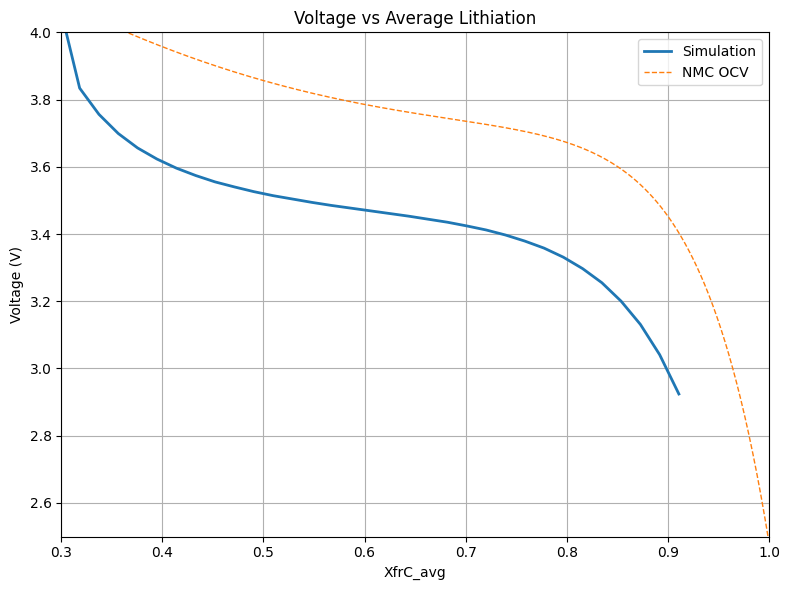

In [55]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/NMC-half-cell-13724576.SLURMout"
)

# ============================================================
# STEP 2: DEFINE OCV FUNCTION
# ============================================================

def ocv_function(c):
    return (
        1.095 * c * c
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )

# Generate smooth OCV curve
c_vals = np.linspace(0.01, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# Interpolated OCV at simulation points
df1["ocv"] = ocv_function(df1["XfrC_avg"])

# ============================================================
# PLOT 1: VOLTAGE VS AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation"
)

plt.plot(
    c_vals,
    ocv_vals,
    "--",
    linewidth=1,
    label="NMC OCV"
)

plt.xlabel("XfrC_avg")
plt.ylabel("Voltage (V)")
plt.xlim(0.3, 1.0)
plt.ylim(2.5, 4.0)
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Plotting the Cell Voltage Curve Against OCV (LFP)

../parameter_sweep_tool/benchmark_runs/20260727_215340_985854_test/logs/job_13747972/run_0003.log
Points found: 287
   XfrC_avg    VCell  Cp_min    Cp_max
0  0.043000  3.45900   0.043  0.043126
1  0.044429  3.42871   0.043  0.045366
2  0.045868  3.41735   0.043  0.046350
3  0.047307  3.40675   0.043  0.047267
4  0.048745  3.39690   0.043  0.048170


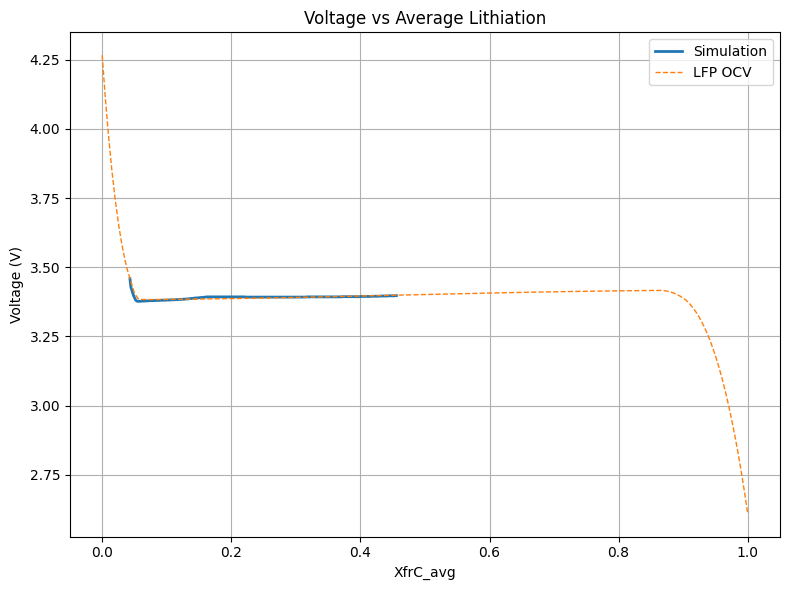

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    # "../MSU_HPCC/LFP-half-cell-13734291.SLURMout")
    "../parameter_sweep_tool/benchmark_runs_2/20260728_081905_104093_test/logs/job_13765643/run_0004.log")

# ============================================================
# LOAD AND CALCULATE LFP OCV
# ============================================================

ticks = np.loadtxt("../inputs/materials/LFP_Chm_Pot_Ticks.txt")
chmPot = np.loadtxt("../inputs/materials/LFP_Chm_Pot.txt")

# Matches MaterialProperties.cpp:
# OCV = -chemical_potential + 3.4
ocv = -chmPot + 3.4

# ============================================================
# PLOT 1: VOLTAGE VS AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation"
)

plt.plot(
    ticks,
    ocv,
    "--",
    linewidth=1,
    label="LFP OCV"
)

plt.xlabel("XfrC_avg")
# plt.xlim(0.195, 0.23)
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Scientific Formatting

Loaded: ../MSU_HPCC/Graphite-half-cell-13727369.SLURMout
Points found: 62
   timestep  XfrC_avg     VCell    Cp_min    Cp_max
0         0  0.030000  0.368600  0.030000  0.030002
1     10000  0.047061  0.208625  0.031250  0.052850
2     20000  0.066153  0.199626  0.037855  0.092416
3     30000  0.085202  0.183229  0.042375  0.117757
4     40000  0.104181  0.158232  0.047553  0.137770


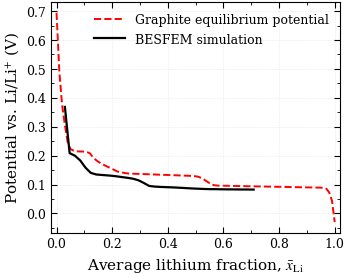

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


# ============================================================
# PUBLICATION-QUALITY MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    # Typography
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Font sizes
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,

    # Lines
    "lines.linewidth": 1.6,

    # Tick marks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    # Saving
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
})


# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[.*?\],\s*"
    r"VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)


def load_data(file_path):
    """
    Parse half-cell simulation output.

    Returns
    -------
    pandas.DataFrame
        Columns:
        timestep, XfrC_avg, VCell, Cp_min, Cp_max
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    text = file_path.read_text()

    matches = pattern.findall(text)

    if not matches:
        raise ValueError(
            f"No simulation data were found in {file_path}.\n"
            "Check whether the field names and their order match the parser."
        )

    data = [
        {
            "timestep": int(timestep),
            "XfrC_avg": float(xfrc),
            "VCell": float(vcell),
            "Cp_min": float(cp_min),
            "Cp_max": float(cp_max),
        }
        for timestep, vcell, cp_min, cp_max, xfrc in matches
    ]

    df = pd.DataFrame(data)

    # Remove duplicate entries and arrange data in physical order.
    df = (
        df.drop_duplicates(subset="timestep")
          .sort_values("timestep")
          .reset_index(drop=True)
    )

    print(f"Loaded: {file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df


# ============================================================
# LOAD SIMULATION DATA
# ============================================================

df1 = load_data(
    "../MSU_HPCC/Graphite-half-cell-13727369.SLURMout"
)


# ============================================================
# LOAD GRAPHITE OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

if ticks.shape != ocv.shape:
    raise ValueError(
        "The graphite stoichiometry and OCV tables have different lengths."
    )

# Sort the OCV table in case its entries are not ordered.
sort_index = np.argsort(ticks)
ticks = ticks[sort_index]
ocv = ocv[sort_index]


# ============================================================
# INTERPOLATE OCV AT SIMULATION POINTS
# ============================================================

df1["OCV"] = np.interp(
    df1["XfrC_avg"],
    ticks,
    ocv
)

df1["overpotential"] = df1["VCell"] - df1["OCV"]


# ============================================================
# PUBLICATION-QUALITY PLOT
# ============================================================

# Approximately 3.5 inches wide for a single journal column.
fig, ax = plt.subplots(figsize=(3.5, 2.8), constrained_layout=True)

# Graphite equilibrium potential.
ax.plot(
    ticks,
    ocv,
    color="red",
    linestyle="--",
    linewidth=1.4,
    label="Graphite equilibrium potential",
    zorder=1
)

# Simulated voltage.
ax.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    color="black",
    linestyle="-",
    # marker="o",
    # markersize=3.5,
    # markeredgewidth=0.6,
    linewidth=1.6,
    label="BESFEM simulation",
    zorder=2
)

# Mathematical notation is preferable to variable names such as XfrC.
ax.set_xlabel(r"Average lithium fraction")
ax.set_ylabel(r"Potential vs. Li/Li$^{+}$ (V)")

# Use the data range automatically, with modest margins.
x_min = min(ticks.min(), df1["XfrC_avg"].min())
x_max = max(ticks.max(), df1["XfrC_avg"].max())
x_margin = 0.02 * (x_max - x_min)

ax.set_xlim(x_min - x_margin, x_max + x_margin)

# Minor ticks improve readability without adding visual clutter.
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

# A faint major grid can be useful; remove this block if the journal
# prefers figures without gridlines.
ax.grid(
    which="major",
    linestyle=":",
    linewidth=0.45,
    alpha=0.45
)

ax.legend(
    loc="best",
    frameon=False,
    handlelength=2.5
)

# ============================================================
# SAVE VECTOR AND HIGH-RESOLUTION RASTER COPIES
# ============================================================

# fig.savefig("graphite_voltage_vs_lithiation.pdf")
# fig.savefig("graphite_voltage_vs_lithiation.svg")
fig.savefig("graphite_voltage_vs_lithiation.png", dpi=600)

plt.show()